In [1]:
import os
import time
import torch
import timm
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

C:\Users\varik\anaconda3\envs\torch_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce GTX 1650


In [3]:
dataset_path = r"C:\Education\Research\Datasets\PlantVillage"

In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [5]:
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

num_classes = len(dataset.classes)

print("Classes:", num_classes)
print("Images:", len(dataset))

Classes: 15
Images: 20638


In [6]:
train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size]
)

In [7]:
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

In [8]:
model = timm.create_model(
    'mobilenetv4_conv_small',
    pretrained=True
)

In [10]:
model.classifier = nn.Linear(
    model.classifier.in_features,
    num_classes
)

model = model.to(device)

In [12]:
params = sum(p.numel() for p in model.parameters())

print(f"Parameters: {params:,}")

Parameters: 2,512,239


In [13]:
criterion = nn.CrossEntropyLoss()

In [14]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [16]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(loader)
    val_acc = 100 * correct / total

    return val_loss, val_acc

In [17]:
num_epochs = 10

best_acc = 0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "mobilenetv4_best.pth"
        )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/10] Train Acc: 86.40% Val Acc: 97.12%
Epoch [2/10] Train Acc: 97.45% Val Acc: 98.13%
Epoch [3/10] Train Acc: 98.64% Val Acc: 98.16%
Epoch [4/10] Train Acc: 98.99% Val Acc: 98.74%
Epoch [5/10] Train Acc: 99.30% Val Acc: 98.55%
Epoch [6/10] Train Acc: 99.33% Val Acc: 98.13%
Epoch [7/10] Train Acc: 99.11% Val Acc: 98.01%
Epoch [8/10] Train Acc: 99.50% Val Acc: 98.28%
Epoch [9/10] Train Acc: 99.45% Val Acc: 97.21%
Epoch [10/10] Train Acc: 99.33% Val Acc: 98.55%


In [18]:
model.load_state_dict(torch.load("mobilenetv4_best.pth"))
model.eval()

C:\Users\varik\AppData\Local\Temp\ipykernel_15500\116639970.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("mobilenetv4_best.pth"))


MobileNetV3(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Iden

In [19]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 98.35%


In [20]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [21]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [22]:
precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

print("Precision:", precision*100)
print("Recall:", recall*100)
print("F1:", f1*100)

Precision: 98.3842768774347
Recall: 98.35351089588377
F1: 98.35532476504923


In [23]:
torch.save(
    model.state_dict(),
    "mobilenetv4_final.pth"
)

In [24]:
import os

size_mb = os.path.getsize(
    "mobilenetv4_final.pth"
)/(1024*1024)

print(f"Model Size: {size_mb:.2f} MB")

Model Size: 9.78 MB


In [25]:
params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Parameters: {params:,}")

Parameters: 2,512,239


In [26]:
from ptflops import get_model_complexity_info

macs, params = get_model_complexity_info(
    model,
    (3,224,224),
    as_strings=True,
    print_per_layer_stat=False
)

print("MACs:", macs)
print("Params:", params)

MACs: 188.28 MMac
Params: 2.51 M


In [27]:
import time

images, labels = next(iter(test_loader))

images = images.to(device)

model.eval()

start = time.time()

with torch.no_grad():
    output = model(images[:1])

end = time.time()

latency = (end-start)*1000

print(f"Latency: {latency:.2f} ms")

Latency: 11.06 ms


In [28]:
fps = 1000 / latency

print(f"FPS: {fps:.2f}")

FPS: 90.43


In [30]:
torch.save(
    model.state_dict(),
    "mobilenetv4_best.pth"
)

# Distilled Mobile_netV3

In [31]:
teacher = timm.create_model(
    'mobilenetv4_conv_small',
    pretrained=False
)

teacher.classifier = nn.Linear(
    teacher.classifier.in_features,
    num_classes
)

teacher.load_state_dict(
    torch.load("mobilenetv4_best.pth")
)

teacher = teacher.to(device)

teacher.eval()

C:\Users\varik\AppData\Local\Temp\ipykernel_15500\1935863230.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("mobilenetv4_best.pth")


MobileNetV3(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Iden

In [32]:
for param in teacher.parameters():
    param.requires_grad = False

In [33]:
from torchvision.models import mobilenet_v3_small
from torchvision.models import MobileNet_V3_Small_Weights

student = mobilenet_v3_small(
    weights=MobileNet_V3_Small_Weights.DEFAULT
)

student.classifier[3] = nn.Linear(
    student.classifier[3].in_features,
    num_classes
)

student = student.to(device)

In [34]:
import torch.nn.functional as F

In [35]:
def distillation_loss(
        student_logits,
        teacher_logits,
        labels,
        T=4,
        alpha=0.7):

    hard_loss = F.cross_entropy(
        student_logits,
        labels
    )

    soft_loss = F.kl_div(
        F.log_softmax(student_logits/T, dim=1),
        F.softmax(teacher_logits/T, dim=1),
        reduction='batchmean'
    ) * (T*T)

    return (
        alpha*soft_loss
        + (1-alpha)*hard_loss
    )

In [36]:
optimizer = torch.optim.Adam(
    student.parameters(),
    lr=0.0001
)

In [37]:
def train_kd(
        student,
        teacher,
        loader,
        optimizer,
        device):

    student.train()

    correct = 0
    total = 0

    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.no_grad():

            teacher_logits = teacher(images)

        student_logits = student(images)

        loss = distillation_loss(
            student_logits,
            teacher_logits,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = student_logits.max(1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    acc = 100*correct/total

    return running_loss/len(loader), acc

In [38]:
num_epochs = 10

for epoch in range(num_epochs):

    loss, acc = train_kd(
        student,
        teacher,
        train_loader,
        optimizer,
        device
    )

    print(
        f"Epoch {epoch+1} "
        f"Loss={loss:.4f} "
        f"Acc={acc:.2f}%"
    )

Epoch 1 Loss=2.4207 Acc=81.59%
Epoch 2 Loss=0.6622 Acc=96.96%
Epoch 3 Loss=0.5098 Acc=98.04%
Epoch 4 Loss=0.4350 Acc=98.46%
Epoch 5 Loss=0.3854 Acc=98.84%
Epoch 6 Loss=0.3504 Acc=99.02%
Epoch 7 Loss=0.3124 Acc=99.25%
Epoch 8 Loss=0.2899 Acc=99.45%
Epoch 9 Loss=0.2783 Acc=99.46%
Epoch 10 Loss=0.2653 Acc=99.45%


In [40]:
def evaluate(model, loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [41]:
val_acc = evaluate(
    student,
    val_loader,
    device
)

print(val_acc)

98.90961957838624


In [42]:
test_acc = evaluate(
    student,
    test_loader,
    device
)

print(test_acc)

99.07990314769975


In [43]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

all_preds = []
all_labels = []

student.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = student(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [44]:
precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")

Precision : 99.09%
Recall    : 99.08%
F1 Score  : 99.08%


In [45]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=dataset.classes
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       103
                     Pepper__bell___healthy       0.99      0.99      0.99       145
                      Potato___Early_blight       1.00      1.00      1.00        92
                       Potato___Late_blight       1.00      1.00      1.00        97
                           Potato___healthy       1.00      1.00      1.00        11
                      Tomato_Bacterial_spot       1.00      0.96      0.98       215
                        Tomato_Early_blight       0.98      0.96      0.97       112
                         Tomato_Late_blight       0.98      1.00      0.99       202
                           Tomato_Leaf_Mold       0.99      1.00      0.99        97
                  Tomato_Septoria_leaf_spot       0.97      1.00      0.99       185
Tomato_Spider_mites_Two_spotted_spider_mite       0.99      0.98

In [47]:
import os

torch.save(
    student.state_dict(),
    "mobilenetv3_distilled.pth"
)

size_mb = os.path.getsize(
    "mobilenetv3_distilled.pth"
)/(1024*1024)

print(f"Model Size: {size_mb:.2f} MB")

Model Size: 5.98 MB


In [48]:
params = sum(
    p.numel()
    for p in student.parameters()
)

print(f"Parameters: {params:,}")

Parameters: 1,533,231


In [49]:
from ptflops import get_model_complexity_info

macs, params = get_model_complexity_info(
    student,
    (3,224,224),
    as_strings=True,
    print_per_layer_stat=False
)

print("MACs :", macs)
print("Params :", params)

MACs : 59.9 MMac
Params : 1.53 M


In [50]:
import time

images, labels = next(iter(test_loader))

images = images.to(device)

student.eval()

start = time.time()

with torch.no_grad():
    _ = student(images[:1])

end = time.time()

latency = (end-start)*1000

fps = 1000/latency

print(f"Inference Time : {latency:.2f} ms")
print(f"FPS            : {fps:.2f}")

Inference Time : 3.89 ms
FPS            : 256.89


In [51]:
torch.save(
    student.state_dict(),
    "mobilenetv3_distilled_fp32.pth"
)

In [52]:
import torch.nn as nn

quantized_model = torch.quantization.quantize_dynamic(
    student.cpu(),
    {nn.Linear},
    dtype=torch.qint8
)

In [53]:
torch.save(
    quantized_model.state_dict(),
    "mobilenetv3_distilled_int8.pth"
)

In [54]:
import os

fp32_size = os.path.getsize(
    "mobilenetv3_distilled_fp32.pth"
)/(1024*1024)

int8_size = os.path.getsize(
    "mobilenetv3_distilled_int8.pth"
)/(1024*1024)

print("FP32 Size :", fp32_size, "MB")
print("INT8 Size :", int8_size, "MB")

FP32 Size : 5.98063850402832 MB
INT8 Size : 4.247549057006836 MB


In [55]:
quantized_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = quantized_model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_acc = 100*correct/total

print(f"INT8 Accuracy: {test_acc:.2f}%")

INT8 Accuracy: 99.08%


In [56]:
import time

images, labels = next(iter(test_loader))

start = time.time()

with torch.no_grad():
    _ = quantized_model(images[:1])

end = time.time()

latency = (end-start)*1000

print(f"Latency: {latency:.2f} ms")

Latency: 35.04 ms


In [57]:
pip install grad-cam

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
     ---- ----------------------------------- 0.8/7.8 MB 5.6 MB/s eta 0:00:02
     -------- ------------------------------- 1.6/7.8 MB 3.2 MB/s eta 0:00:02
     ------------- -------------------------- 2.6/7.8 MB 3.8 MB/s eta 0:00:02
     ----------------- ---------------------- 3.4/7.8 MB 3.8 MB/s eta 0:00:02
     --------------------- ------------------ 4.2/7.8 MB 3.9 MB/s eta 0:00:01
     -------------------------- ------------- 5.2/7.8 MB 4.1 MB/s eta 0:00:01
     --------------------------------- ------ 6.6/7.8 MB 4.3 MB/s eta 0:00:01
     ---------------------------------------- 7.8/7.8 MB 4.5 MB/s  0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata 

In [58]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [59]:
student.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [60]:
print(student.features)

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (2): Hardswish()
  )
  (1): InvertedResidual(
    (block): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): SqueezeExcitation(
        (avgpool): AdaptiveAvgPool2d(output_size=1)
        (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
        (activation): ReLU()
        (scale_activation): Hardsigmoid()
      )
      (2): Conv2dNormActivation(
        (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, mo

In [61]:
target_layers = [student.features[-2]]

In [69]:
img_path=r"C:\Education\Research\Datasets\PlantVillage\Potato___Late_blight\01ad74ce-eb28-42c7-9204-778d17cfd45c___RS_LB 2669.JPG"

In [70]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img = Image.open(img_path).convert('RGB')

input_tensor = transform(img).unsqueeze(0)

input_tensor = input_tensor.to(device)

In [71]:
cam = GradCAM(
    model=student,
    target_layers=target_layers
)

In [72]:
grayscale_cam = cam(
    input_tensor=input_tensor
)

grayscale_cam = grayscale_cam[0]

In [73]:
rgb_img = np.array(
    img.resize((224,224))
).astype(np.float32) / 255.0

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

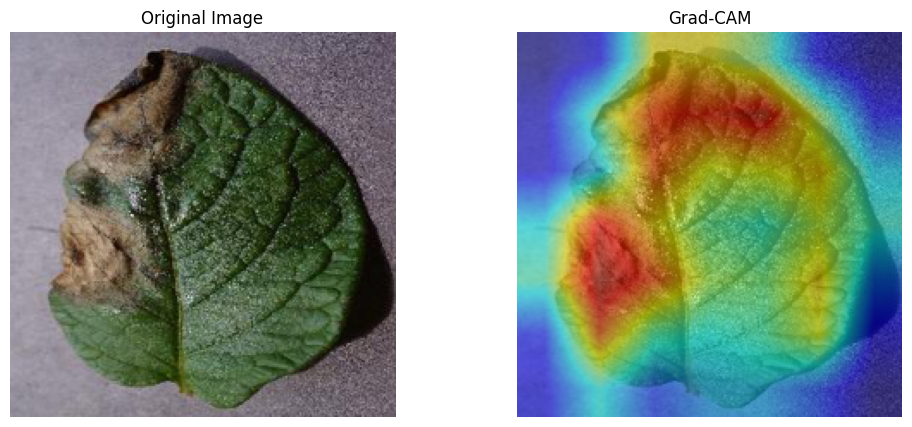

In [74]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()